# **IMC ROUND ONE/TWO**

## **Imports**

In [1]:
# allowed packages
import pandas as pd 
import numpy as np 
import statistics as stats
#import math
#import typing
#import jsonpickle # conda install jsonpickle 
# extra packages 
import matplotlib.pyplot as plt
from collections import defaultdict

## **Data Pre-Processing**

In [91]:
def missing_count(data: pd.DataFrame): 
    """
    count nas 
    """
    dat: defaultdict = defaultdict()
    for col in data.columns:
        dat[col] = int(data[col].isna().sum())

    return dat

def read_data(paths: list, book = True) -> dict[str, list]: 
    """
    combine books for seperate products
    """
    books: dict = {}
    keys = None
    
    agg_by = 'symbol'
    if book: 
        agg_by = 'product'

    for day, path in enumerate(paths):
        # dataframe
        dat: pd.DataFrame = pd.read_csv(path, sep = ';')
        dat.loc[:, 'day'] = day
        # split per product
        if not books:
            keys = dat[agg_by].unique()
        for k in keys:
            last_book = books[k] if k in books else None
            current_data = dat.loc[dat[agg_by] == k]
            books[k] = pd.concat([last_book, current_data], axis = 0)
    
    return books

def standerdise_timestamp(data): 
    """
    combine timestamp inplace 
    """
    n = data.shape[0]
    data.loc[:, 'timestamp'] = [i for i in range(0, 100*n, 100)]

def clean_book(data): 
    """
    clean data inplace 
    """
    data.replace({'mid_price': 0.0}, np.nan, inplace = True)
    data['mid_price'].ffill(inplace=True)

def total_vols(data: pd.DataFrame):
    """
    aggragates level_2 volume data in level_2 book 
    """
    data.fillna(0, inplace = True)
    bid_vols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
    ask_vols = ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']
    data = data.assign(
        total_bid_volume = data.loc[:, bid_vols].sum(axis = 1), 
        total_ask_volume = data.loc[:, ask_vols].sum(axis = 1)
    )
    return data 

def data_pre_process(paths: list, book = True):
    """
    data pre-process pipeline 
    """
    df = read_data(paths, book)
    x1, x2 = df['ASH_COATED_OSMIUM'], df['INTARIAN_PEPPER_ROOT']
    # create timestamp 
    standerdise_timestamp(x1)
    standerdise_timestamp(x2)
    # clean data 
    if book:
        clean_book(x1)
        clean_book(x2)
        x1 = total_vols(x1)
        x2 = total_vols(x2)

    return x1, x2

# total trade data   
paths_prices = [
    'data_round_1/prices_round_1_day_-2.csv', 
    'data_round_1/prices_round_1_day_-1.csv', 
    'data_round_1/prices_round_1_day_0.csv'
]
x1_book, x2_book = data_pre_process(paths_prices)

# market trades data 
paths_trades = [
    'data_round_1/trades_round_1_day_-2.csv',
    'data_round_1/trades_round_1_day_-1.csv',
    'data_round_1/trades_round_1_day_0.csv'
]

x1_market, x2_market = data_pre_process(paths_trades, False)

/var/folders/mg/82w1c_cd6r3cv72tkghtghkm0000gn/T/ipykernel_63772/2077014105.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['mid_price'].ffill(inplace=True)


## **EDA**

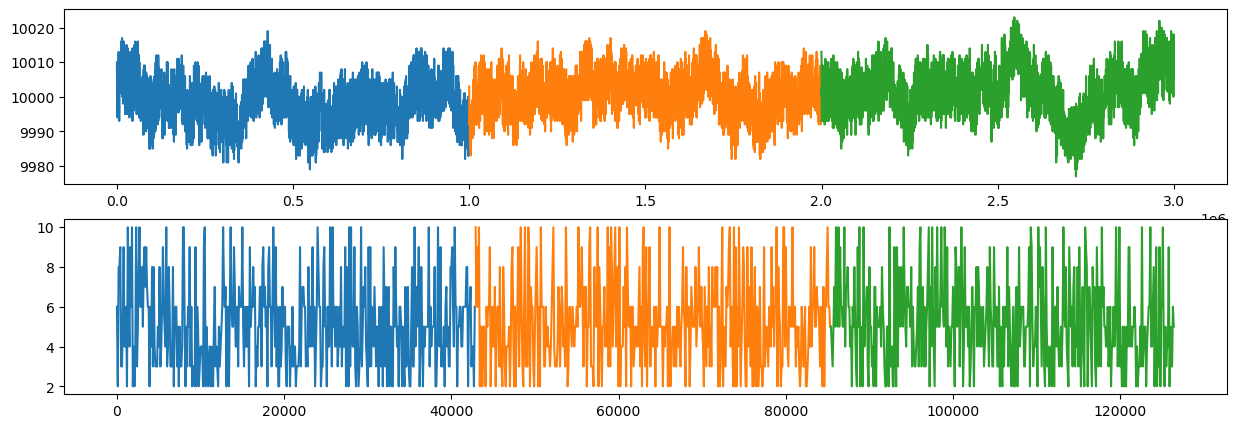

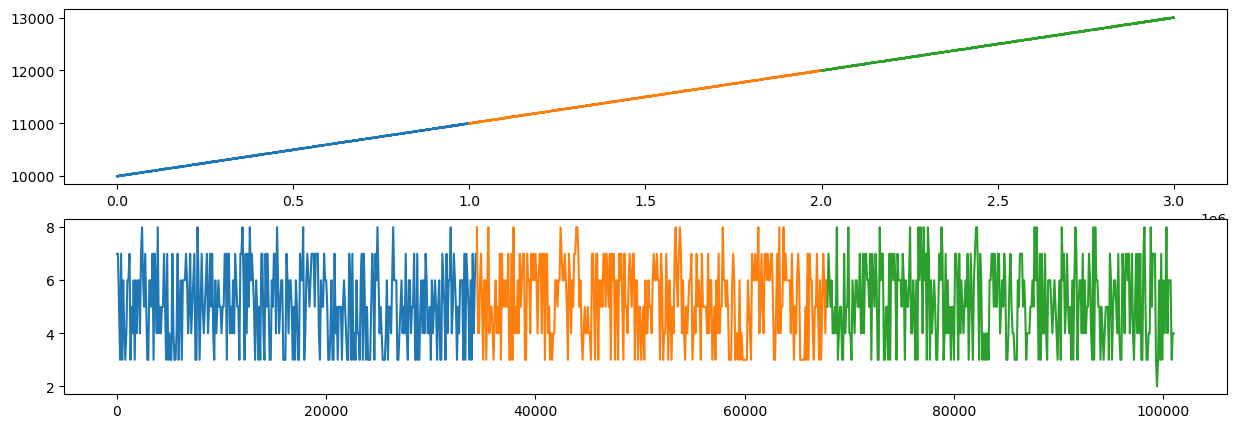

In [118]:
def plot_mids(x: pd.DataFrame, 
              feature: str, 
              ax, 
              title: str = 'product'):
    """
    plot mid prices 
    """
    # filter data by day
    xday1 = x.loc[x.day == 0]
    xday2 = x.loc[x.day == 1]
    xday3 = x.loc[x.day == 2]

    # plot 
    ax.plot(xday1.timestamp, getattr(xday1, feature))
    ax.plot(xday2.timestamp, getattr(xday2, feature))
    ax.plot(xday3.timestamp, getattr(xday3, feature))

# x1   
product1 = 'ASH_COATED_OSMIUM'
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 5))
plot_mids(x1_book, 'mid_price', ax[0], title = 'ASH Mid Price')
plot_mids(x1_market, 'quantity', ax[1], title = 'ASH Market Order Quantity')

# x2
product2 = 'INTARIAN_PEPPER_ROOT'
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 5))
plot_mids(x2_book, 'mid_price', ax[0], title = 'PEPPER Mid Price')
plot_mids(x2_market, 'quantity', ax[1], title = 'PEPPER Market Order Quantity')

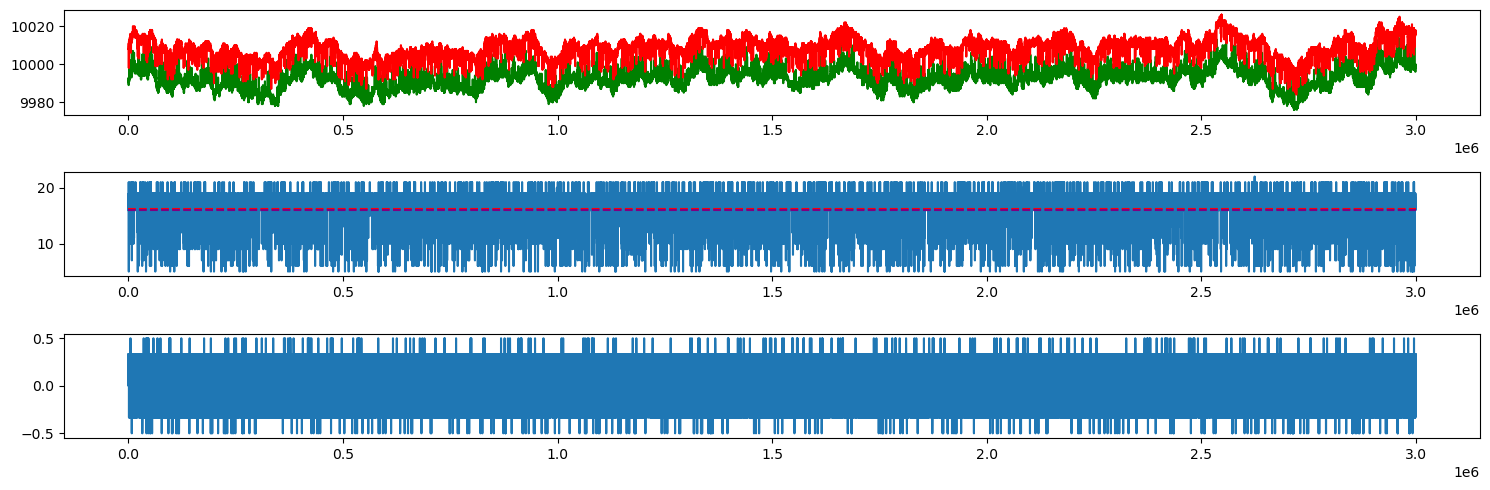

In [117]:
def spread(data: pd.DataFrame): 
    """
    plots spread
    """
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize = (15, 5))
    # spread
    data = data.loc[(data['bid_price_1']!=0) & 
                    (data['ask_price_1']!=0), :]
    best_bid = data['bid_price_1']
    best_ask = data['ask_price_1']
    ax[0].plot(data['timestamp'], data['bid_price_1'], color = 'g')
    ax[0].plot(data['timestamp'], data['ask_price_1'], color = 'r')
    # spread difference
    spread_diff = best_ask - best_bid
    avg_spread = np.mean(spread_diff)
    median_spread = np.median(spread_diff)
    ax[1].plot(data['timestamp'], spread_diff)
    ax[1].hlines(avg_spread, data['timestamp'].values[0], data['timestamp'].values[-1], color = 'r', linestyle = '--') 
    ax[1].hlines(median_spread, data['timestamp'].values[0], data['timestamp'].values[-1], color = 'purple', linestyle = '--') 
    # imbalance
    all_bid_v = data['bid_price_1'] + data['bid_price_2'] + data['bid_price_3']
    all_ask_v = data['ask_price_1'] + data['ask_price_2'] + data['ask_price_3']
    imbalance = (all_ask_v - all_bid_v) / (all_bid_v + all_ask_v)
    ax[2].plot(data['timestamp'], imbalance)

    plt.tight_layout();
spread(x1_book)

## **Model 1 PRODUCT1**

In [6]:
def data_quantiles(data: pd.DataFrame, q_feature: str):
    """
    bins y_label based on quantiles of q_feature 
    """

    book = data.assign(y_label = x1_book['mid_price'].pct_change().fillna(0))

    q_25 = book[q_feature].quantile(q = 0.25)
    q_50 = book[q_feature].quantile(q = 0.50)
    q_75 = book[q_feature].quantile(q = 0.75)

    # subset
    x_q_25 = book.loc[book[q_feature] <= q_25, [q_feature, 'y_label']]
    x_q_50 = book.loc[(book[q_feature] > q_25) & 
                (book[q_feature] <= q_50), [q_feature, 'y_label']]
    x_q_75 = book.loc[(book[q_feature] > q_50) & 
                (book[q_feature] <= q_75), [q_feature, 'y_label']]
    x_q_100 = book.loc[book[q_feature] > q_75, [q_feature, 'y_label']]

    return {
        'data': book,
        'xy_25': x_q_25, 
        'xy_50': x_q_50, 
        'xy_75': x_q_75, 
        'xy_100': x_q_100
    }

# plot
def plot_qs(x_25, x_50, x_75, x_100, q_feature, axis, title = ''):
    """
    plots four quantiles 
    """
    axis.set_title(title)
    axis.scatter(x_25[q_feature].values, x_25['y_label'].values)
    axis.scatter(x_50[q_feature].values, x_50['y_label'].values)
    axis.scatter(x_75[q_feature].values, x_75['y_label'].values)
    axis.scatter(x_100[q_feature].values, x_100['y_label'].values)

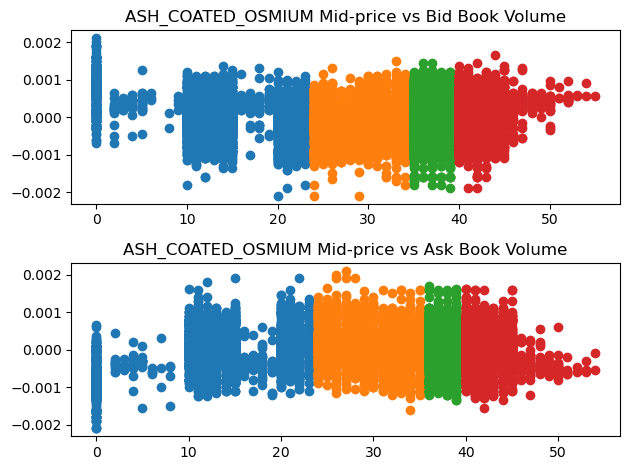

In [7]:
# datasets 
xy_bids = data_quantiles(x1_book, 'total_bid_volume')
xy_asks = data_quantiles(x1_book, 'total_ask_volume')

# plot 
fig, ax = plt.subplots(nrows = 2, ncols = 1)
plot_qs(xy_bids['xy_25'], xy_bids['xy_50'], xy_bids['xy_75'], xy_bids['xy_100'], 'total_bid_volume', ax[0], title = f'{product1} Mid-price vs Bid Book Volume')
plot_qs(xy_asks['xy_25'], xy_asks['xy_50'], xy_asks['xy_75'], xy_asks['xy_100'], 'total_ask_volume', ax[1], title = f'{product1} Mid-price vs Ask Book Volume')
plt.tight_layout();

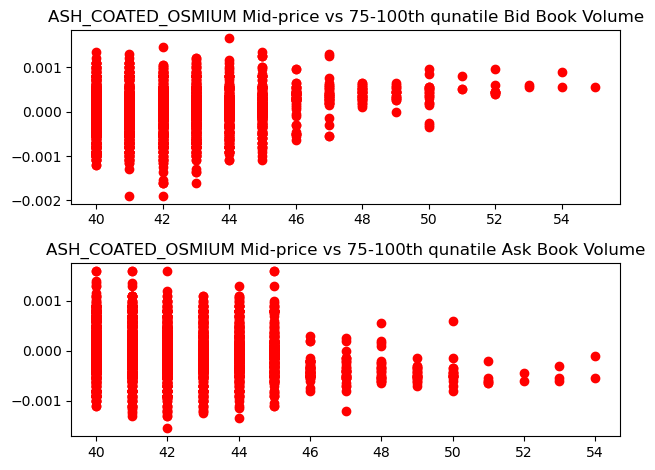

In [8]:
fig, ax = plt.subplots(nrows = 2, ncols=1)
ax[0].set_title(f'{product1} Mid-price vs 75-100th qunatile Bid Book Volume')
ax[0].scatter(xy_bids['xy_100']['total_bid_volume'], xy_bids['xy_100']['y_label'], color = 'r')

ax[1].set_title(f'{product1} Mid-price vs 75-100th qunatile Ask Book Volume')
ax[1].scatter(xy_asks['xy_100']['total_ask_volume'], xy_asks['xy_100']['y_label'], color = 'r')
plt.tight_layout();


In [9]:
# polynomial regression 
def regression_polynomial(data, q_feature, poly: int = 2):
    """
    generlaised polynomial regression 
    """
    x = data[q_feature].values
    X = np.ones((poly, len(x)))
    # polynomial feature vectors 
    for i in range(poly+1):
        X[i:, ] = np.pow(x, i)

    Y = data['y_label'].values
    Xt = X.transpose()
    XXt = X @ Xt
    XXtinv = np.linalg.inv(XXt)
    XtY = X @ Y
    params = XXtinv @ XtY

    return {
        'parameters': params, 
        'data': x,
        'label': Y
    }

def regression_polynomial_predict(data, parameters): 
    """
    predict function for generalised polynomial regression
    """
    slope = parameters[0]
    coeffs = parameters[1:]
    yhat = slope
    for pow, c in enumerate(coeffs): 
        yhat += c*data**(pow+1)

    return yhat

def plot_regression(reg_res, axis, title): 
    """
    plots regression 
    """
    min_x, max_x = min(reg_res['data']), max(reg_res['data'])
    x_sort = np.linspace(min_x, max_x, 100)
    yhat = regression_polynomial_predict(x_sort, reg_res['parameters'])
    # plot
    axis.set_title(title)
    axis.scatter(reg_res['data'], reg_res['label'])
    axis.plot(x_sort, yhat, color = 'r')

### **Model Fit/Predict**

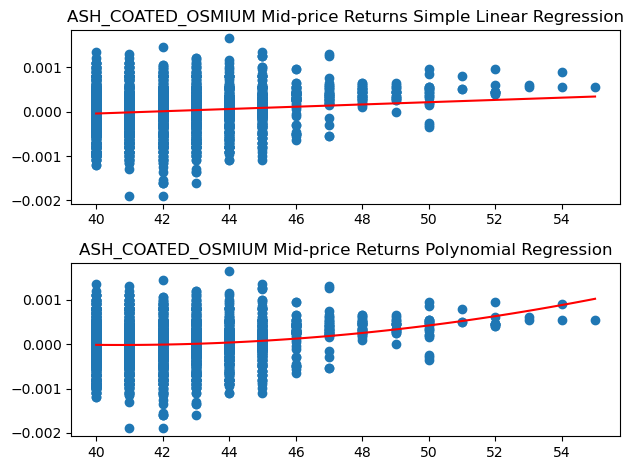

In [10]:
# fit models 
reg_slr = regression_polynomial(xy_bids['xy_100'], 'total_bid_volume', 2)
poly_reg = regression_polynomial(xy_bids['xy_100'], 'total_bid_volume', 3)

# plot
fig, ax = plt.subplots(nrows = 2, ncols = 1)
plot_regression(reg_slr, ax[0], f'{product1} Mid-price Returns Simple Linear Regression')
plot_regression(poly_reg, ax[1], f'{product1} Mid-price Returns Polynomial Regression')
plt.tight_layout()

### **Binning Features**

In [11]:
def bin_data(data, q_feature):
    """
    bins function 
    """
    x = data[q_feature]
    y = data['y_label']
    bins = np.linspace(x.min(), x.max(), 30) 
    bin_indicies = np.digitize(x, bins)

    x_binned = []
    y_binned = []
    for i in range(1, len(bins)):
        mask = bin_indicies == i
        if np.any(mask): 
            x_binned.append(x[mask].mean())
            y_binned.append(y[mask].mean())
    x_binned = np.array(x_binned)
    y_binned = np.array(y_binned)

    xy_bin = pd.DataFrame({
    q_feature: x_binned, 
    'y_label': y_binned
    })

    return xy_bin

xy_bin_bids = bin_data(xy_bids['xy_100'], 'total_bid_volume')
xy_bin_asks = bin_data(xy_asks['xy_100'], 'total_ask_volume')

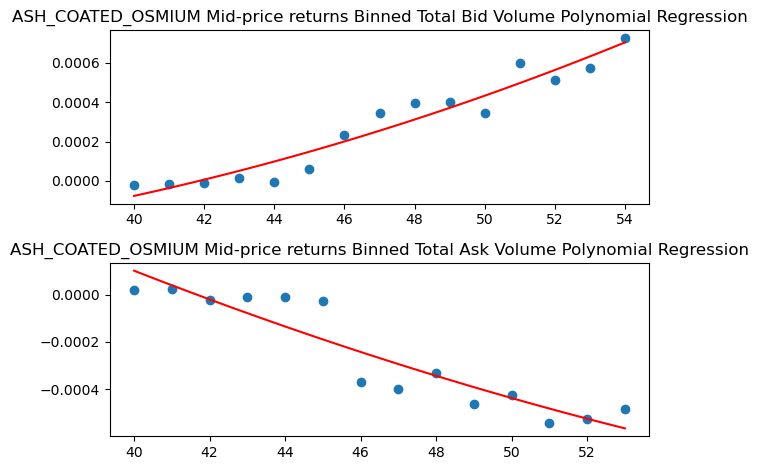

In [12]:
# fit
poly_reg_bins_bid = regression_polynomial(xy_bin_bids, 'total_bid_volume', 3)
poly_reg_bins_ask = regression_polynomial(xy_bin_asks, 'total_ask_volume', 3)

# predict 
yhat_bin_bid = regression_polynomial_predict(poly_reg_bins_bid['data'], poly_reg_bins_bid['parameters'])
yhat_bin_ask = regression_polynomial_predict(poly_reg_bins_ask['data'], poly_reg_bins_ask['parameters'])

# plot 
fig, ax = plt.subplots(nrows = 2, ncols = 1)
plot_regression(poly_reg_bins_bid, ax[0], f'{product1} Mid-price returns Binned Total Bid Volume Polynomial Regression')
plot_regression(poly_reg_bins_ask, ax[1], f'{product1} Mid-price returns Binned Total Ask Volume Polynomial Regression')
plt.tight_layout();

## **Model 1 PRODUCT2**

b0= 9999.987095180166 , b1= 0.10000060034133385


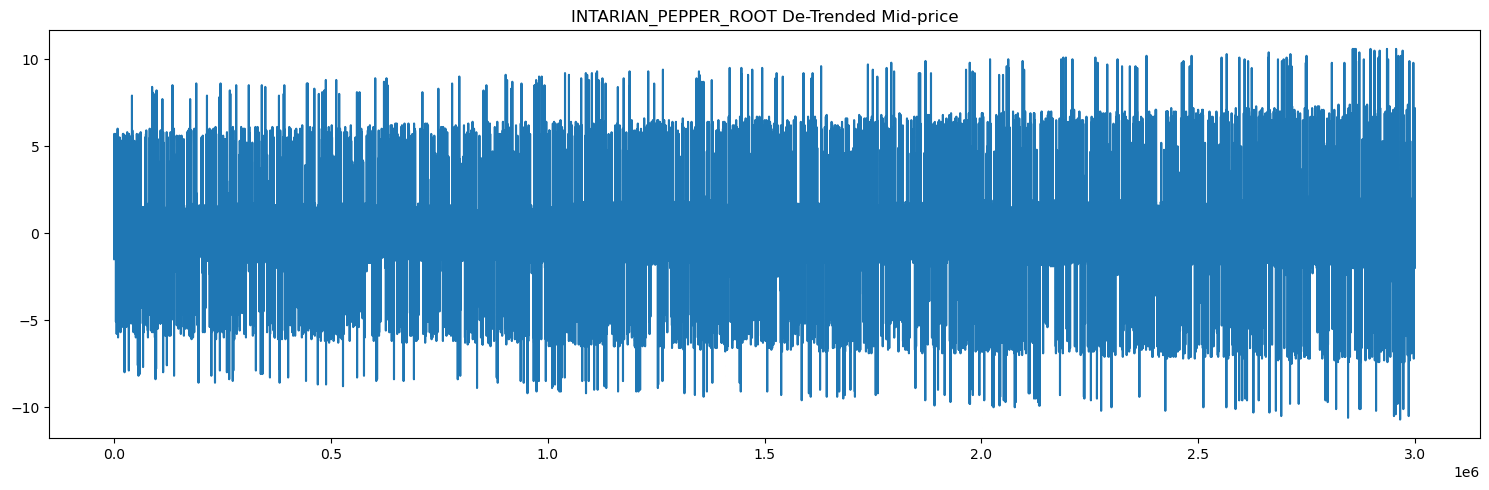

In [145]:
import code_round_1.my_algo as my_algo

# de-trend product 2
x2_book = x2_book.assign(
    y_label = x2_book['mid_price'], 
    t = np.arange(0, x2_book.shape[0])
)
de_trend_poly_reg = regression_polynomial(x2_book, 't')
print('b0=', de_trend_poly_reg['parameters'][0], ', b1=', de_trend_poly_reg['parameters'][1])
de_trend_reg = regression_polynomial_predict(x2_book['t'], de_trend_poly_reg['parameters'])
x2_book = x2_book.assign(
    mid_price_de_trend = x2_book['y_label'] - de_trend_reg,
    de_trend_returns  = x2_book['mid_price_de_trend'].pct_change().shift(-1).fillna(0)
)

# plot de-trended series 
fig, ax  = plt.subplots(figsize = (15, 5))
ax.set_title(f'{my_algo.PRODUCT2} De-Trended Mid-price')
ax.plot(x2_book['timestamp'], x2_book['mid_price_de_trend'])
plt.tight_layout();

conditional expetations

In [153]:
n = x2_book.shape[0]
up_outliers = x2_book.loc[x2_book['mid_price_de_trend'] > 6, :]
down_outliers = x2_book.loc[x2_book['mid_price_de_trend'] < -6, :]

# empirical conditional expectations
up_outlier_followed_down_day = len(up_outliers.loc[up_outliers['de_trend_returns']<0])/len(up_outliers)
down_oulier_followed_up_day = len(down_outliers.loc[down_outliers['de_trend_returns']>0])/len(down_outliers)

print('E[down_move_t+1 | up_oulier_t] =', up_outlier_followed_down_day)
print('E[up_move_t+1 | down_outlier_t] =', down_oulier_followed_up_day)

E[down_move_t+1 | up_oulier_t] = 0.9920993227990971
E[up_move_t+1 | down_outlier_t] = 0.026615969581749048


## **Book Probability Measure**

0.30929390199000373 0.3089860198741776


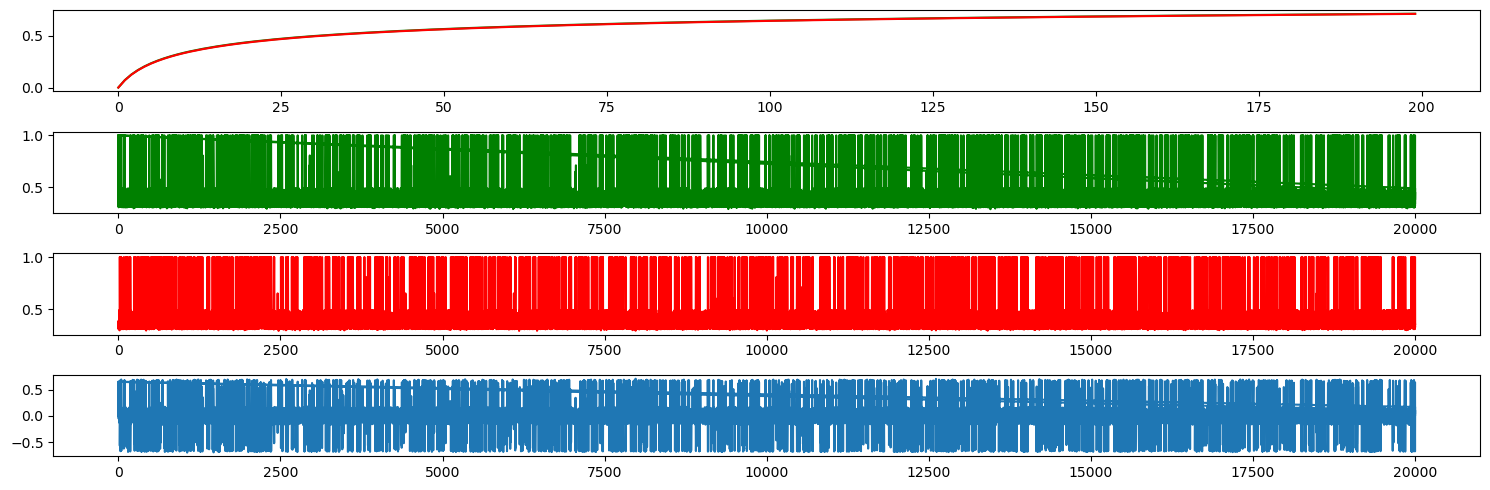

In [119]:
# enforce min values to avoud overflow 
x1_book.loc[x1_book['total_bid_volume'] == 0, 'total_bid_volume'] = 1
x1_book.loc[x1_book['total_ask_volume'] == 0, 'total_ask_volume'] = 1

# compute empirical pareto MLE
x1_book_bid_k = len(x1_book) / np.sum(np.log(x1_book['total_bid_volume']))
x1_book_ask_k = len(x1_book) / np.sum(np.log(x1_book['total_ask_volume']))
print(x1_book_bid_k, x1_book_ask_k)

# cdf for bids and asks 
x1_book_q_bids_sort = np.linspace(min(x1_book['total_bid_volume']), max(x1_book['total_bid_volume']), 200)
x1_book_q_asks_sort = np.linspace(min(x1_book['total_ask_volume']), max(x1_book['total_ask_volume']), 200)

x1_book_bids_comp_cdf = np.pow(1/x1_book_q_bids_sort, x1_book_bid_k)
x1_book_asks_comp_cdf = np.pow(1/x1_book_q_asks_sort, x1_book_ask_k)

# point densities 
x1_book_bid_sf = np.pow(1/x1_book['total_bid_volume'], x1_book_bid_k)
x1_book_ask_sf = np.pow(1/x1_book['total_ask_volume'], x1_book_ask_k)

# dominate side 
book_dom_side = x1_book_bid_sf - x1_book_ask_sf

# plot 
fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (15, 5))
ax[0].plot(1-x1_book_bids_comp_cdf, color = 'g')
ax[0].plot(1-x1_book_asks_comp_cdf, color = 'r')
ax[1].plot(x1_book_bid_sf, color = 'g')
ax[2].plot(x1_book_ask_sf, color = 'r')
ax[3].plot(book_dom_side)
plt.tight_layout();

empirical conditional expectations